Это нужно, чтобы заработал selenium

In [11]:
%%shell
wget -q -O /tmp/chrome.deb https://dl.google.com/linux/direct/google-chrome-stable_current_amd64.deb
apt-get install -y /tmp/chrome.deb > /dev/null 2>&1
google-chrome --version

Google Chrome 148.0.7778.178 


Установка библиотек и импорты

In [12]:
!pip install selenium webdriver-manager -q

import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import re
from dataclasses import dataclass, field
from typing import Optional
import warnings
warnings.filterwarnings('ignore')

from selenium import webdriver
from selenium.webdriver.chrome.options import Options
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from bs4 import BeautifulSoup

plt.rcParams.update({
    'figure.facecolor': '#FAFAFA',
    'axes.facecolor': '#FAFAFA',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'figure.dpi': 150,
})
PALETTE = ['#6C5CE7', '#00B894', '#FDCB6E', '#E17055', '#0984E3', '#D63031']

Модели данных

In [13]:
@dataclass
class Vacancy:
    title: str
    salary_from: Optional[float]
    salary_to: Optional[float]
    currency: str = 'RUR'
    experience: str = ''
    schedule: str = ''
    employer: str = ''
    source: str = ''

    @property
    def salary_mid(self) -> Optional[float]:
        if self.salary_from and self.salary_to:
            return (self.salary_from + self.salary_to) / 2
        return self.salary_from or self.salary_to


@dataclass
class Position:
    name: str
    search_query: str | list
    count: int = 1
    vacancies: list = field(default_factory=list)

Сбор данных: API Работа России (trudvsem.ru)

In [14]:
class TrudvsemApiCollector:

    BASE_URL = 'http://opendata.trudvsem.ru/api/v1/vacancies'
    SOURCE_NAME = 'trudvsem.ru'

    def __init__(self, region_code='7700000000000'):
        self.region_code = region_code
        self.session = requests.Session()
        self.session.headers.update({
            'User-Agent': 'FlowerShopAnalysis/1.0',
            'Accept': 'application/json',
        })

    def search_vacancies(self, query, limit=100):
        url = f'{self.BASE_URL}/region/{self.region_code}'
        params = {'text': query, 'limit': limit, 'offset': 0}
        try:
            resp = self.session.get(url, params=params, timeout=20)
            resp.raise_for_status()
            return self._parse(resp.json())
        except Exception as e:
            print(f'  Ошибка trudvsem для "{query}": {e}')
            return []

    def _parse(self, data):
        result = []
        items = data.get('results', {}).get('vacancies', []) or data.get('vacancies', []) or []

        for item in items:
            raw = item.get('vacancy', item)
            title = raw.get('job-name') or raw.get('vacancy_name') or raw.get('name', '')

            company = raw.get('company')
            if isinstance(company, dict):
                employer = company.get('name', '')
            elif isinstance(company, str):
                employer = company
            else:
                employer = ''

            salary_from = self._num(raw.get('salary_min') or raw.get('salary'))
            salary_to = self._num(raw.get('salary_max'))

            schedule = raw.get('schedule') or raw.get('work_hours') or ''
            req = raw.get('requirement', {})
            experience = req.get('experience', '') if isinstance(req, dict) else ''

            v = Vacancy(
                title=title, salary_from=salary_from, salary_to=salary_to,
                experience=experience, schedule=schedule,
                employer=employer, source=self.SOURCE_NAME,
            )
            if v.salary_mid and v.salary_mid > 0:
                result.append(v)

        return result

    @staticmethod
    def _num(val):
        if val in [None, '', 'null']:
            return None
        try:
            return float(val)
        except (ValueError, TypeError):
            return None

    def collect(self, positions):
        for pos in positions:
            queries = pos.search_query if isinstance(pos.search_query, list) else [pos.search_query]
            collected = []
            for q in queries:
                found = self.search_vacancies(q)
                print(f'  [trudvsem] "{q}" -- {len(found)} вакансий')
                collected.extend(found)
                time.sleep(0.5)
            pos.vacancies = collected
            print(f'  Итого trudvsem "{pos.name}": {len(pos.vacancies)}\n')

Сбор данных: парсинг hh.ru через Selenium


In [15]:
class HHSeleniumCollector:
    """
    Парсинг hh.ru через headless Chrome.
    API hh.ru закрыт с декабря 2025, поэтому парсим HTML напрямую.
    """

    BASE_URL = 'https://hh.ru/search/vacancy'
    SOURCE_NAME = 'hh.ru'

    def __init__(self, area_id=1, max_pages=3):
        self.area_id = area_id
        self.max_pages = max_pages
        self.driver = self._start_browser()

    def _start_browser(self):
        from webdriver_manager.chrome import ChromeDriverManager
        from selenium.webdriver.chrome.service import Service as ChromeService

        opts = Options()
        opts.binary_location = '/usr/bin/google-chrome'
        opts.add_argument('--headless=new')
        opts.add_argument('--no-sandbox')
        opts.add_argument('--disable-dev-shm-usage')
        opts.add_argument('--disable-gpu')
        opts.add_argument('--window-size=1920,1080')
        opts.add_argument(
            'user-agent=Mozilla/5.0 (Windows NT 10.0; Win64; x64) '
            'AppleWebKit/537.36 (KHTML, like Gecko) Chrome/137.0.0.0 Safari/537.36'
        )

        svc = ChromeService(ChromeDriverManager().install())
        driver = webdriver.Chrome(service=svc, options=opts)
        driver.set_page_load_timeout(30)
        return driver

    def search_vacancies(self, query):
        all_found = []
        for page in range(self.max_pages):
            url = (
                f'{self.BASE_URL}?text={query}'
                f'&area={self.area_id}&only_with_salary=true'
                f'&items_on_page=50&page={page}'
            )
            try:
                self.driver.get(url)
                WebDriverWait(self.driver, 10).until(
                    EC.presence_of_element_located((By.CSS_SELECTOR, '[data-qa="vacancy-serp__results"]'))
                )
                time.sleep(2)

                soup = BeautifulSoup(self.driver.page_source, 'html.parser')
                parsed = self._extract_vacancies(soup)
                all_found.extend(parsed)

                if not soup.select_one('[data-qa="pager-next"]'):
                    break
                time.sleep(np.random.uniform(2, 4))

            except Exception as e:
                print(f'    ошибка на стр.{page}: {e}')
                break

        return all_found

    def _extract_vacancies(self, soup):
        cards = soup.select('[data-qa="vacancy-serp__vacancy"]')
        cards += soup.select('[data-qa="vacancy-serp__vacancy vacancy-serp-item_clickme"]')

        result = []
        seen = set()
        for card in cards:
            try:
                v = self._parse_card(card)
                if v and v.salary_mid and v.salary_mid > 0:
                    key = (v.title, v.employer, v.salary_from, v.salary_to)
                    if key not in seen:
                        seen.add(key)
                        result.append(v)
            except Exception:
                continue
        return result

    def _parse_card(self, card):
        # название
        el = card.select_one('[data-qa="serp-item__title"]')
        title = el.get_text(strip=True) if el else ''
        if not title:
            return None

        # работодатель
        el = card.select_one('[data-qa="vacancy-serp__vacancy-employer-text"]')
        employer = el.get_text(strip=True) if el else ''

        # опыт
        el = card.select_one('[data-qa*="work-experience"]')
        experience = el.get_text(strip=True) if el else ''

        # зарплата -- достаём из текста карточки, т.к. отдельного data-qa нет
        text = card.get_text(' ', strip=True)
        m = re.search(r'(от\s*)?(до\s*)?([\d\s]+)\s*[–—-]\s*([\d\s]+)\s*₽', text)
        if not m:
            m = re.search(r'(от|до)?\s*([\d\s]+)\s*₽', text)
        if not m:
            return None

        sal_from, sal_to = self._extract_salary(m)
        if sal_from is None and sal_to is None:
            return None

        return Vacancy(
            title=title, salary_from=sal_from, salary_to=sal_to,
            experience=experience, employer=employer, source=self.SOURCE_NAME,
        )

    @staticmethod
    def _extract_salary(match):
        raw = match.group(0).replace('\xa0', ' ').replace('\u202f', ' ')
        nums = [int(n.replace(' ', '')) for n in re.findall(r'[\d\s]+', raw) if n.strip()]
        if not nums:
            return None, None
        if len(nums) >= 2:
            return float(nums[0]), float(nums[1])
        if 'от' in raw.lower():
            return float(nums[0]), None
        if 'до' in raw.lower():
            return None, float(nums[0])
        return float(nums[0]), float(nums[0])

    def collect(self, positions):
        for pos in positions:
            queries = pos.search_query if isinstance(pos.search_query, list) else [pos.search_query]
            batch = []
            for q in queries:
                found = self.search_vacancies(q)
                print(f'  [hh.ru] "{q}" -- {len(found)} вакансий')
                batch.extend(found)
                time.sleep(np.random.uniform(2, 4))
            pos.vacancies.extend(batch)
            print(f'  Итого hh.ru "{pos.name}": {len(batch)}\n')

    def close(self):
        try:
            self.driver.quit()
        except Exception:
            pass


Мульти-источник — объединение и дедупликация

In [16]:
def collect_from_all_sources(positions, collectors):
    for pos in positions:
        pos.vacancies = []

    for coll in collectors:
        src_name = coll.__class__.__name__
        print(f'--- {src_name} ---')
        coll.collect(positions)

    print('Дедупликация')
    total = 0
    for pos in positions:
        before = len(pos.vacancies)
        unique = {}
        for v in pos.vacancies:
            key = (v.title.lower().strip(), v.employer.lower().strip(), v.salary_from, v.salary_to)
            unique[key] = v
        pos.vacancies = list(unique.values())
        removed = before - len(pos.vacancies)
        total += len(pos.vacancies)
        note = f', -{removed} дубл.' if removed else ''
        print(f'  {pos.name}: {len(pos.vacancies)} уникальных{note}')

    print(f'\nВсего вакансий: {total}')

Запуск сбора данных

In [17]:
import shutil
chrome_path = shutil.which('google-chrome') or shutil.which('chromium-browser')
print(f'Chrome: {chrome_path}\n')

positions = [
    Position('Флорист',
             ['флорист', 'продавец-флорист', 'цветы', 'цветочный'], count=2),
    Position('Продавец-консультант',
             ['продавец-консультант', 'продавец', 'кассир', 'работник торгового зала'], count=2),
    Position('Курьер',
             ['курьер', 'курьер доставка'], count=2),
    Position('Администратор магазина',
             ['администратор магазина', 'администратор торгового зала', 'старший продавец', 'управляющий магазином'], count=1),
    Position('SMM-менеджер',
             ['SMM', 'маркетолог', 'менеджер по рекламе', 'контент-менеджер'], count=1),
    Position('Бухгалтер (аутсорс)',
             ['бухгалтер'], count=1),
]

trudvsem = TrudvsemApiCollector(region_code='7700000000000')
hh = HHSeleniumCollector(area_id=1, max_pages=2)

collect_from_all_sources(positions, [trudvsem, hh])
hh.close()

# проверка минимального количества
for p in positions:
    if len(p.vacancies) < 3:
        print(f'Внимание: мало данных для "{p.name}" ({len(p.vacancies)} шт.)')

Chrome: /usr/bin/google-chrome

--- TrudvsemApiCollector ---
  [trudvsem] "флорист" -- 0 вакансий
  [trudvsem] "продавец-флорист" -- 0 вакансий
  [trudvsem] "цветы" -- 37 вакансий
  [trudvsem] "цветочный" -- 12 вакансий
  Итого trudvsem "Флорист": 49

  [trudvsem] "продавец-консультант" -- 99 вакансий
  [trudvsem] "продавец" -- 100 вакансий
  [trudvsem] "кассир" -- 99 вакансий
  [trudvsem] "работник торгового зала" -- 92 вакансий
  Итого trudvsem "Продавец-консультант": 390

  [trudvsem] "курьер" -- 97 вакансий
  [trudvsem] "курьер доставка" -- 98 вакансий
  Итого trudvsem "Курьер": 195

  [trudvsem] "администратор магазина" -- 100 вакансий
  [trudvsem] "администратор торгового зала" -- 100 вакансий
  [trudvsem] "старший продавец" -- 100 вакансий
  [trudvsem] "управляющий магазином" -- 99 вакансий
  Итого trudvsem "Администратор магазина": 399

  [trudvsem] "SMM" -- 15 вакансий
  [trudvsem] "маркетолог" -- 16 вакансий
  [trudvsem] "менеджер по рекламе" -- 13 вакансий
  [trudvsem] "конт

Класс анализа зарплат и total cost

In [18]:
class SalaryAnalyzer:

    INSURANCE_RATE = 0.15  # страховые взносы 15%

    def __init__(self, positions):
        self.positions = positions
        self.df = self._to_dataframe()

    def _to_dataframe(self):
        rows = []
        for pos in self.positions:
            for v in pos.vacancies:
                if not v.salary_mid:
                    continue
                rows.append({
                    'position': pos.name,
                    'vacancy_title': v.title,
                    'employer': v.employer,
                    'salary_from': v.salary_from,
                    'salary_to': v.salary_to,
                    'salary_mid': v.salary_mid,
                    'experience': v.experience,
                    'schedule': v.schedule,
                    'source': v.source,
                    'count_needed': pos.count,
                })
        return pd.DataFrame(rows)

    def summary_stats(self):
        stats = self.df.groupby('position')['salary_mid'].agg(
            ['mean', 'median', 'std', 'min', 'max', 'count']
        ).round(0)
        stats.columns = ['Среднее', 'Медиана', 'Ст.откл.', 'Мин', 'Макс', 'N']
        return stats

    def total_cost_table(self):
        rows = []
        for pos in self.positions:
            salaries = [v.salary_mid for v in pos.vacancies if v.salary_mid]
            if not salaries:
                continue
            median_sal = np.median(salaries)
            insurance = median_sal * self.INSURANCE_RATE
            cost_per_person = median_sal + insurance
            cost_total = cost_per_person * pos.count

            rows.append({
                'Позиция': pos.name,
                'Кол-во': pos.count,
                'Медиана ЗП': round(median_sal),
                'Страх. взносы (15%)': round(insurance),
                'Total cost / чел.': round(cost_per_person),
                'Total cost x штат': round(cost_total),
            })
        return pd.DataFrame(rows)

    def experience_breakdown(self):
        ct = pd.crosstab(self.df['position'], self.df['experience'], normalize='index') * 100
        return ct.round(1)

    def source_breakdown(self):
        ct = pd.crosstab(self.df['position'], self.df['source'])
        ct['Всего'] = ct.sum(axis=1)
        return ct

Запуск анализа и вывод таблиц

In [19]:
analyzer = SalaryAnalyzer(positions)

print('Сводная статистика зарплат (руб/мес)')
display(analyzer.summary_stats())

print('\nРаспределение по источникам')
display(analyzer.source_breakdown())

print('\nTotal Cost для компании')
tc = analyzer.total_cost_table()
display(tc)

total_m = tc['Total cost x штат'].sum()
print(f'\nИТОГО ФОТ: {total_m:,.0f} руб/мес  |  {total_m * 12:,.0f} руб/год')

Сводная статистика зарплат (руб/мес)


,Среднее,Медиана,Ст.откл.,Мин,Макс,N
position,,,,,,
SMM-менеджер,116338.0,100000.0,63297.0,520.0,425000.0,421
Администратор магазина,104631.0,97500.0,32844.0,27500.0,310000.0,396
Бухгалтер (аутсорс),117765.0,100000.0,52446.0,39730.0,400000.0,195
Курьер,123272.0,102500.0,70014.0,700.0,378500.0,233
Продавец-консультант,77680.0,78500.0,26809.0,1650.0,215000.0,375
Флорист,99167.0,85000.0,79297.0,3250.0,675000.0,236



Распределение по источникам


source,hh.ru,trudvsem.ru,Всего
position,,,
SMM-менеджер,376,45,421
Администратор магазина,298,98,396
Бухгалтер (аутсорс),103,92,195
Курьер,114,119,233
Продавец-консультант,251,124,375
Флорист,191,45,236



Total Cost для компании


,Позиция,Кол-во,Медиана ЗП,Страх. взносы (15%),Total cost / чел.,Total cost x штат
0,Флорист,2,85000,12750,97750,195500
1,Продавец-консультант,2,78500,11775,90275,180550
2,Курьер,2,102500,15375,117875,235750
3,Администратор магазина,1,97500,14625,112125,112125
4,SMM-менеджер,1,100000,15000,115000,115000
5,Бухгалтер (аутсорс),1,100000,15000,115000,115000



ИТОГО ФОТ: 953,925 руб/мес  |  11,447,100 руб/год


In [20]:
out_df = analyzer.df.copy()
out_df = out_df.sort_values(['position', 'salary_mid']).reset_index(drop=True)
out_df = out_df.rename(columns={
    'position': 'Должность',
    'salary_from': 'ЗП от',
    'salary_to': 'ЗП до',
    'salary_mid': 'Средняя ЗП',
    'experience': 'Опыт',
    'schedule': 'График',
    'source': 'Источник',
    'count_needed': 'Кол-во в штате',
})

display(out_df)

file_name = 'all_vacancies_flower_shop.xlsx'
out_df.to_excel(file_name, index=False)
print(f'Сохранено: {file_name}')

from google.colab import files
files.download(file_name)

,Должность,vacancy_title,employer,ЗП от,ЗП до,Средняя ЗП,Опыт,График,Источник,Кол-во в штате
0,SMM-менеджер,Агент по недвижимости / Стажер / Риэлтор ( м. ...,Vysotsky Estate,350.0,690.0,520.0,Без опыта,,hh.ru,1
1,SMM-менеджер,Контент-креатор/UGC/блогер,ОООМакротранс,10000.0,NaN,10000.0,Без опыта,,hh.ru,1
2,SMM-менеджер,Менеджер ЦИАН,ИП Елин Максим Сергеевич,5000.0,15000.0,10000.0,Опыт 1-3 года,,hh.ru,1
3,SMM-менеджер,Менеджер по рекламе,ИП Салтыков Валерий Германович,15000.0,NaN,15000.0,Опыт 1-3 года,,hh.ru,1
4,SMM-менеджер,Трендвотчер / Контент-аналитик / Контент-менеджер,ООО ВИТА,16000.0,NaN,16000.0,Без опыта,,hh.ru,1
...,...,...,...,...,...,...,...,...,...,...
1851,Флорист,Программист-разработчик 1С,7ЦВЕТОВ,270000.0,270000.0,270000.0,Опыт 1-3 года,,hh.ru,2
1852,Флорист,Категорийный менеджер ФРОВ (Овощи/Фрукты/Цветы),"Красное & Белое, розничная сеть",NaN,300000.0,300000.0,Опыт 1-3 года,,hh.ru,2
1853,Флорист,Менеджер по оптовым продажам/Хантер,7ЦВЕТОВ,200000.0,800000.0,500000.0,Опыт 1-3 года,,hh.ru,2
1854,Флорист,Менеджер по оптовым продажам (Хантер),7ЦВЕТОВ,200000.0,800000.0,500000.0,Опыт 1-3 года,,hh.ru,2


Сохранено: all_vacancies_flower_shop.xlsx


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Класс визуализации

In [23]:
class StaffVisualizer:

    def __init__(self, analyzer):
        self.an = analyzer
        self.df = analyzer.df

    def salary_boxplot(self):
        fig, ax = plt.subplots(figsize=(12, 6))
        order = self.df.groupby('position')['salary_mid'].median().sort_values(ascending=True).index
        bp = ax.boxplot(
            [self.df[self.df['position'] == p]['salary_mid'] / 1000 for p in order],
            labels=order, vert=False, patch_artist=True,
            medianprops=dict(color='black', linewidth=2),
            flierprops=dict(marker='o', alpha=0.4, markersize=4),
        )
        for patch, c in zip(bp['boxes'], PALETTE):
            patch.set_facecolor(c)
            patch.set_alpha(0.7)
        ax.set_xlabel('Зарплата, тыс. руб/мес')
        ax.set_title('Распределение зарплат по позициям (Москва)', pad=15)
        median_all = self.df['salary_mid'].median() / 1000
        ax.axvline(x=median_all, color='gray', ls='--', alpha=0.5, label='Общая медиана')
        ax.legend()
        plt.tight_layout()
        plt.show()

    def total_cost_bars(self):
        tc = self.an.total_cost_table()
        fig, ax = plt.subplots(figsize=(12, 6))
        y = np.arange(len(tc))
        sal = tc['Медиана ЗП'] / 1000
        ins = tc['Страх. взносы (15%)'] / 1000

        ax.barh(y, sal, 0.5, label='Оклад (gross)', color=PALETTE[0], alpha=0.85)
        ax.barh(y, ins, 0.5, left=sal, label='Страховые взносы 15%', color=PALETTE[1], alpha=0.85)

        for i, row in tc.iterrows():
            t = row['Total cost / чел.'] / 1000
            ax.text(t + 1, i, f'{t:.0f}k', va='center', fontweight='bold')

        ax.set_yticks(y)
        ax.set_yticklabels(tc['Позиция'])
        ax.set_xlabel('тыс. руб/мес')
        ax.set_title('Структура Total Cost на 1 сотрудника', pad=15)
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.08), ncol=2)
        plt.tight_layout()
        plt.show()

    def budget_pie_and_bar(self):
        tc = self.an.total_cost_table()
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
        labels = tc['Позиция']
        vals = tc['Total cost x штат'] / 1000

        ax1.pie(vals, autopct='%1.0f%%', colors=PALETTE[:len(labels)],
                startangle=90, pctdistance=0.75, textprops={'fontsize': 10})
        ax1.legend(labels, loc='lower left', fontsize=9)
        ax1.set_title(f'Доли в ФОТ (итого {vals.sum():.0f}k руб/мес)', pad=15)

        y = np.arange(len(labels))
        bars = ax2.barh(y, vals, color=PALETTE[:len(labels)], alpha=0.85, height=0.5)
        ax2.set_yticks(y)
        ax2.set_yticklabels(labels)
        ax2.set_xlabel('тыс. руб/мес')
        ax2.set_title('Месячный бюджет по позициям (с учетом штата)', pad=15)
        for bar, v in zip(bars, vals):
            ax2.text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                     f'{v:.0f}k', va='center', fontweight='bold')
        plt.tight_layout()
        plt.show()

    def experience_heatmap(self):
        exp = self.an.experience_breakdown()
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.heatmap(exp, annot=True, fmt='.0f', cmap='YlGnBu',
                    ax=ax, cbar_kws={'label': '% вакансий'}, linewidths=0.5)
        ax.set_title('Требуемый опыт по позициям, %', pad=15)
        ax.set_ylabel('')
        ax.set_xlabel('')
        plt.tight_layout()
        plt.show()

    def salary_violin(self):
        fig, ax = plt.subplots(figsize=(12, 6))
        order = self.df.groupby('position')['salary_mid'].median().sort_values(ascending=False).index.tolist()
        sns.violinplot(data=self.df, x='salary_mid', y='position', order=order,
                       palette=PALETTE, inner='quartile', ax=ax, alpha=0.8, scale='width', cut=0)
        ax.set_xlabel('Зарплата, руб/мес')
        ax.set_ylabel('')
        ax.set_title('Плотность распределения зарплат', pad=15)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
        plt.tight_layout()
        plt.show()

    def source_comparison(self):
        sources = self.df['source'].unique()
        if len(sources) < 2:
            print('Один источник, сравнение не требуется')
            return
        fig, ax = plt.subplots(figsize=(12, 6))
        colors = {'trudvsem.ru': PALETTE[2], 'hh.ru': PALETTE[4]}
        pal = {s: colors.get(s, PALETTE[3]) for s in sources}
        sns.boxplot(data=self.df, x='salary_mid', y='position', hue='source', palette=pal, ax=ax)
        ax.set_xlabel('Зарплата, руб/мес')
        ax.set_ylabel('')
        ax.set_title('Сравнение зарплат по источникам', pad=15)
        ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x/1000:.0f}k'))
        ax.legend(title='Источник')
        plt.tight_layout()
        plt.show()

Генерация графиков

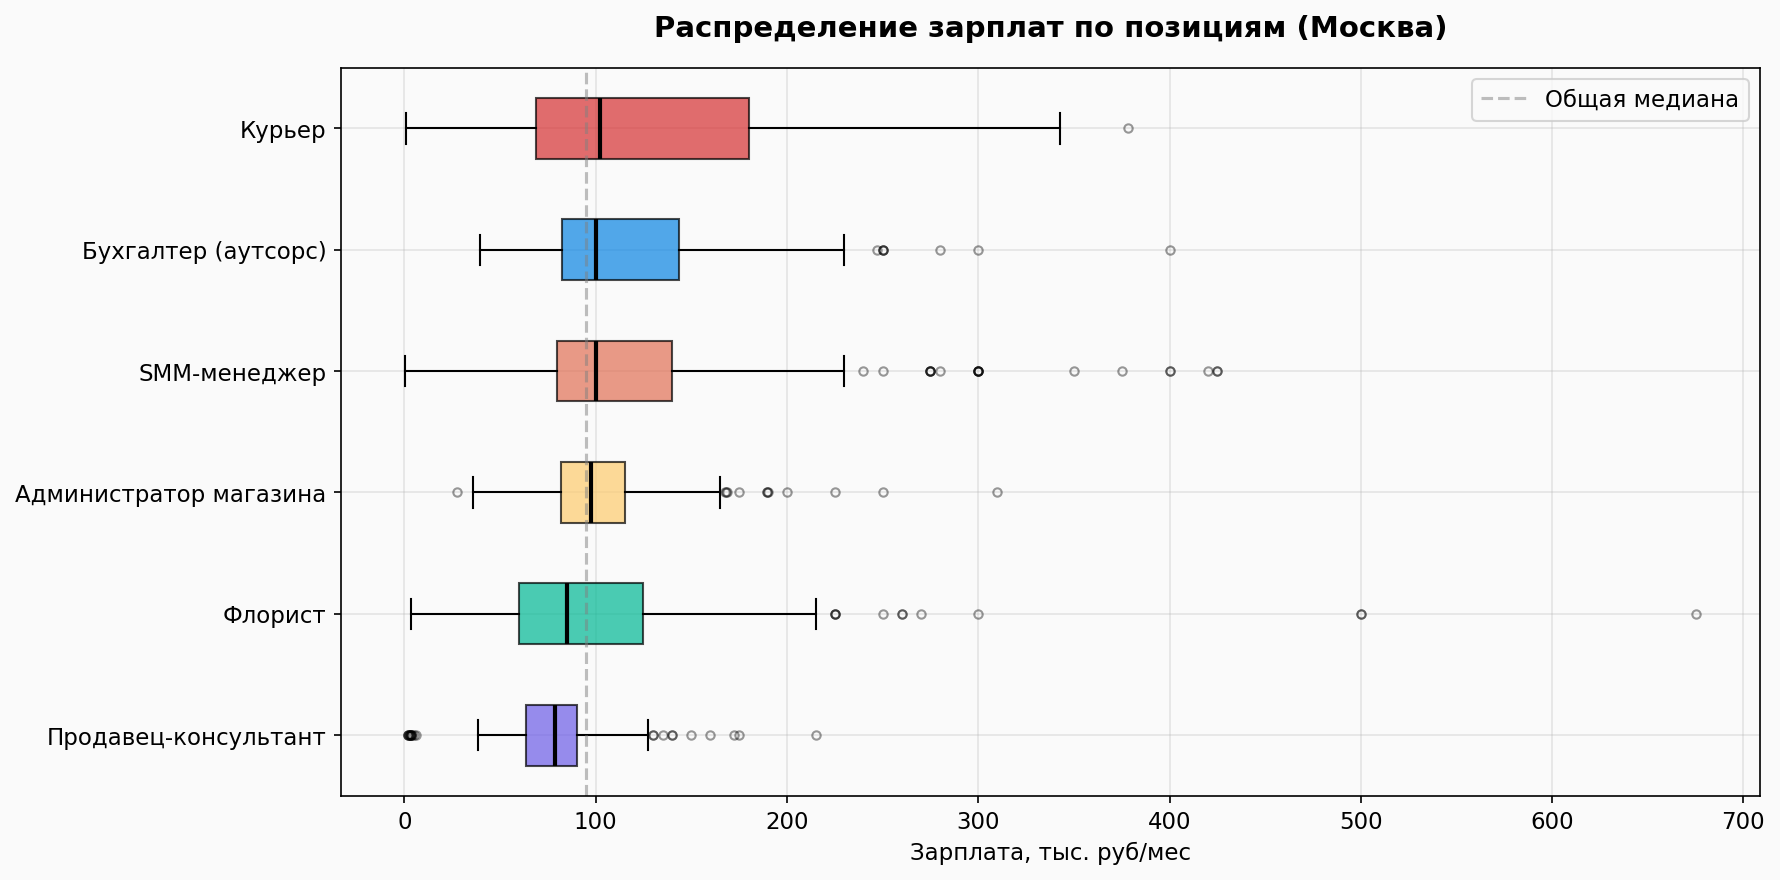

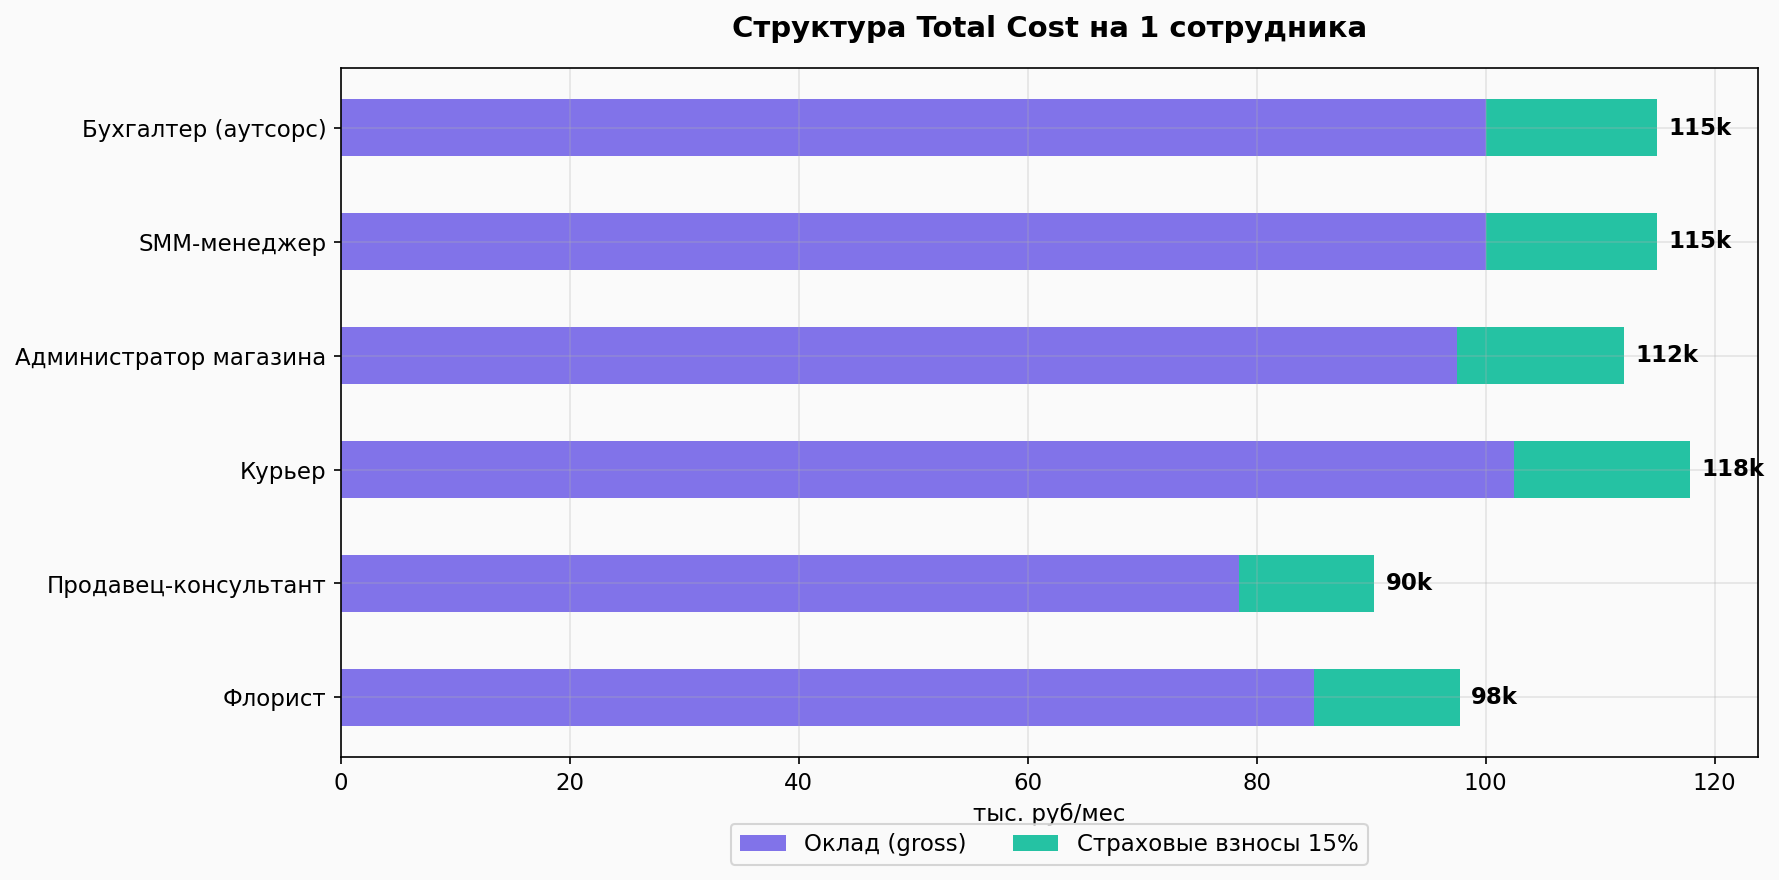

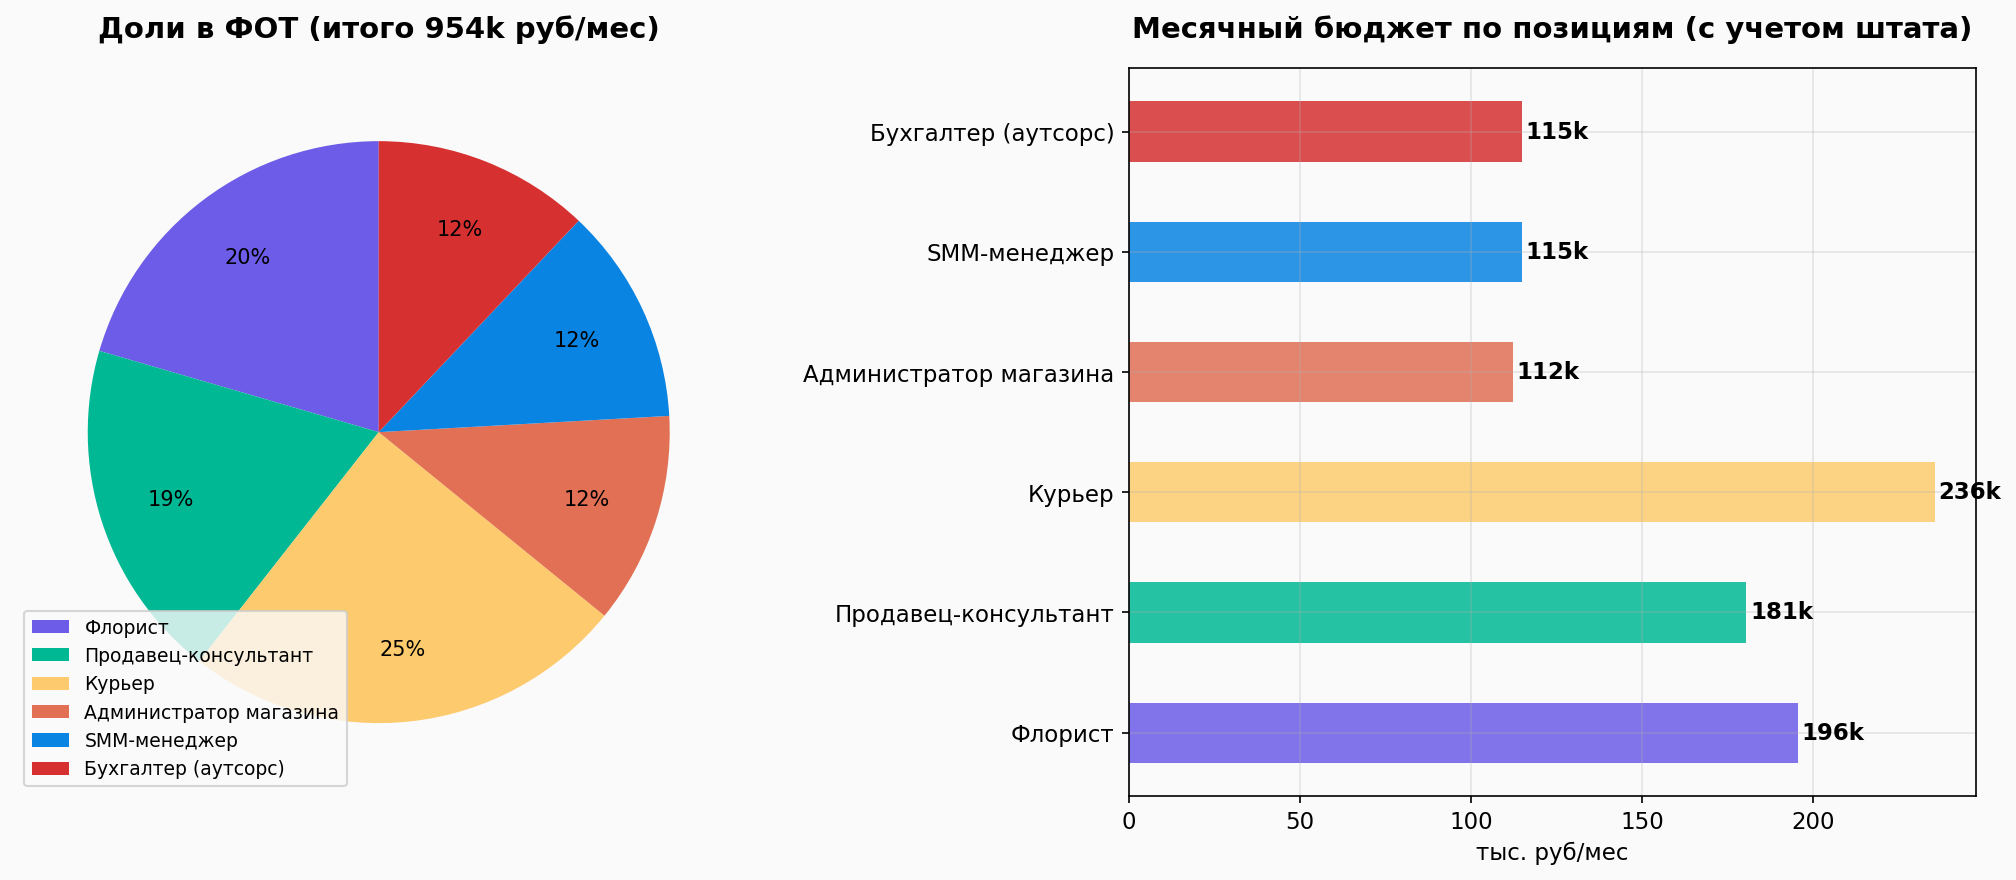

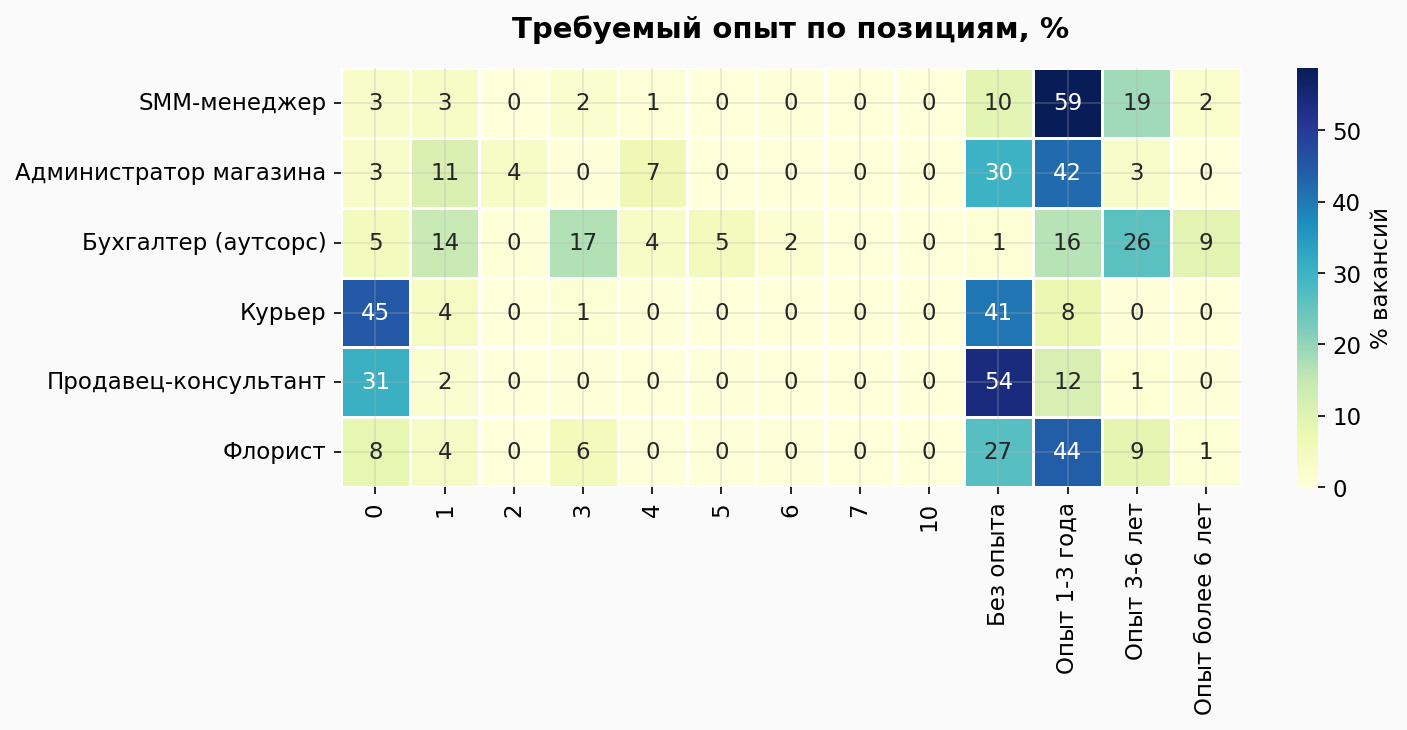

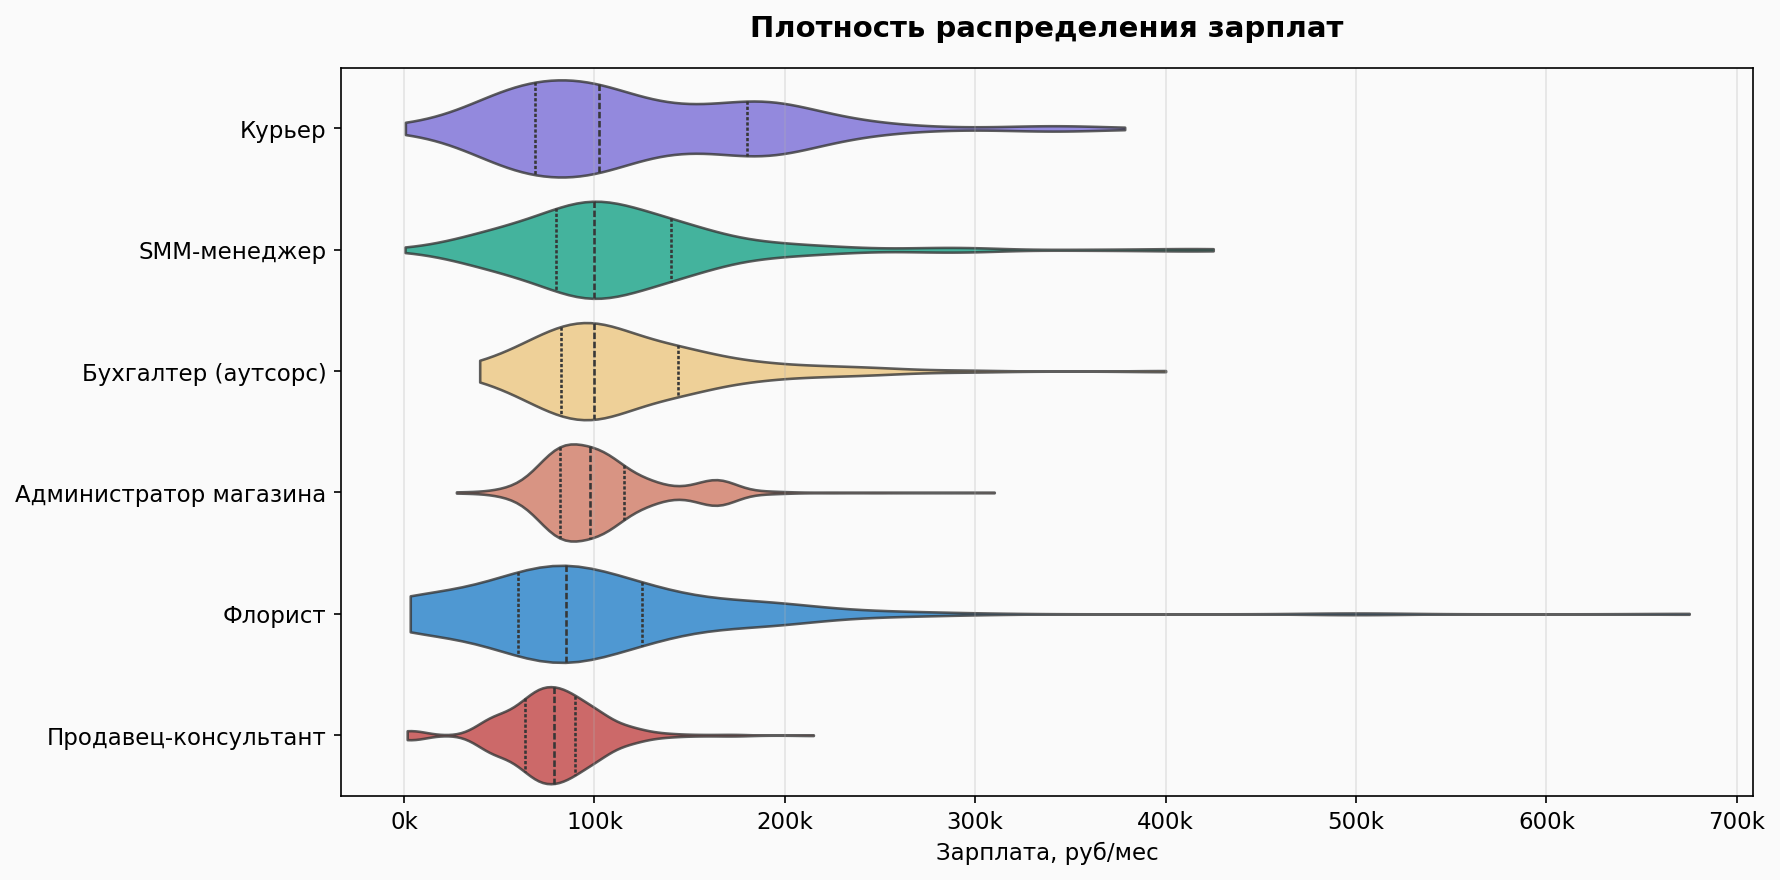

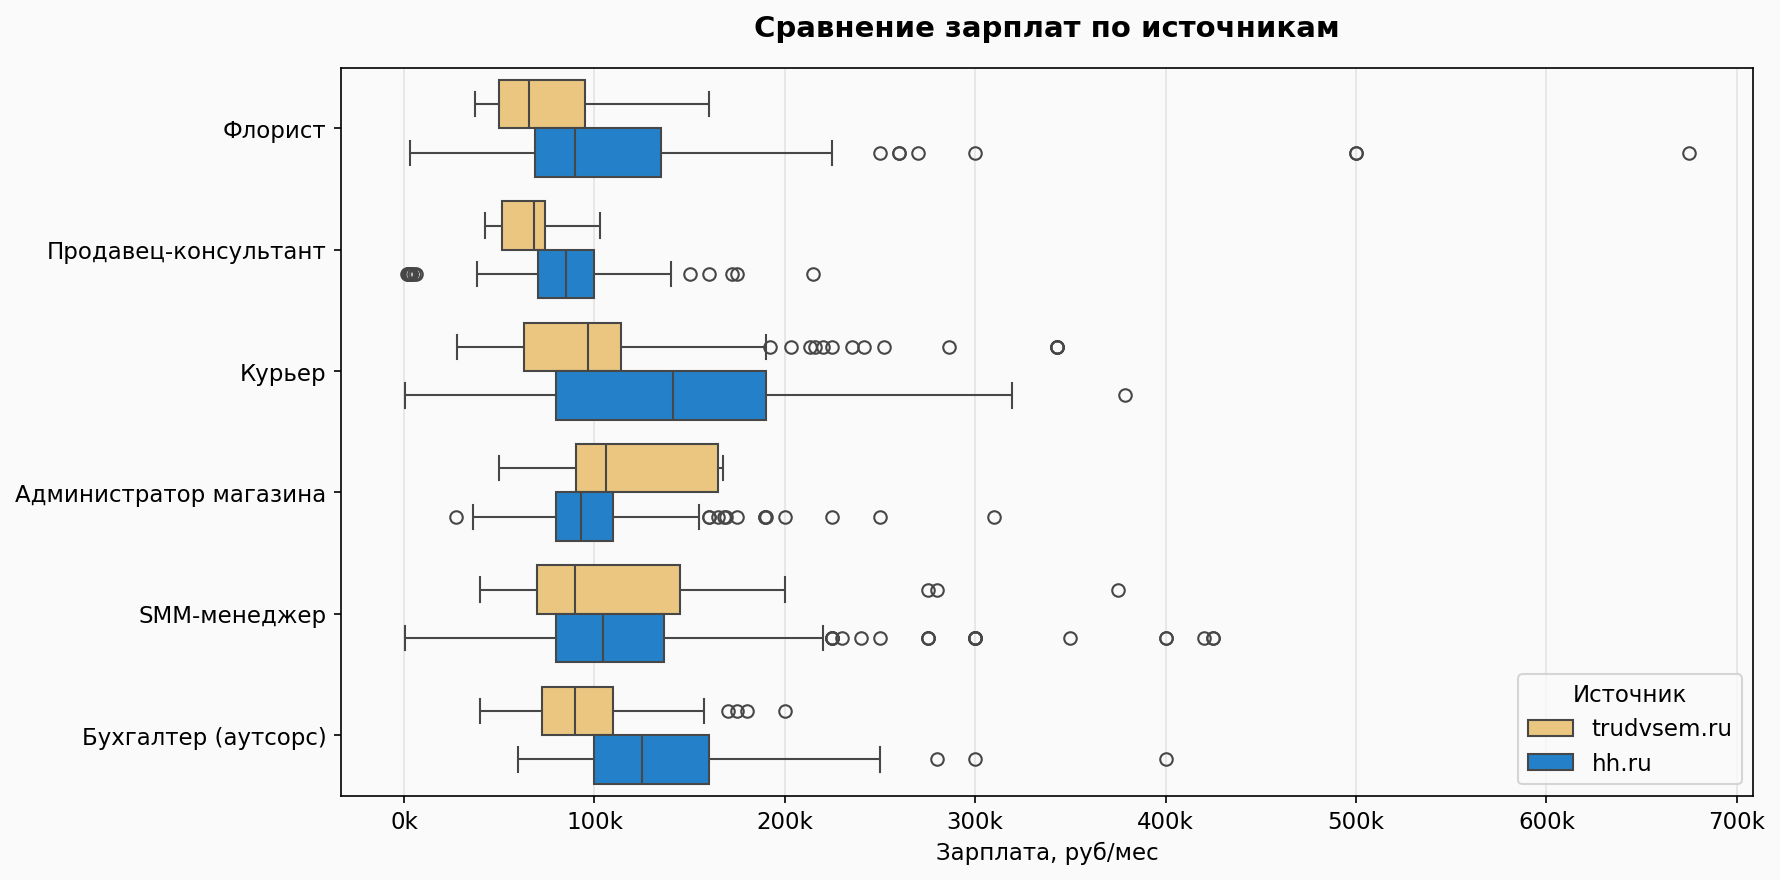

In [24]:
viz = StaffVisualizer(analyzer)

viz.salary_boxplot()
viz.total_cost_bars()
viz.budget_pie_and_bar()
viz.experience_heatmap()
viz.salary_violin()
viz.source_comparison()